# Form 4 Sentiment Event Study Draft

??????????????????? notebook?????? `Form 4` ?????????????????????????? market-model ?????

????????????

- ???????? `close_adj.csv` ???????????? `market_ret`????????????????? Fama-French ?????
- ??????????????????????????????????????????????

???????????????????????????????????????????? notebook ???


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / 'data'
CLOSE_ADJ_PATH = DATA_DIR / 'close_adj.csv'
OUTPUT_DIR = DATA_DIR / 'results' / '4' / 'event_study_draft'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALIGNED_DIR_CANDIDATES = [
    DATA_DIR / 'results' / '4' / 'aligned_sentiment_timeseries',
    DATA_DIR / 'results' / '4' / 'aligned_sentiment_timeseries_test',
]

aligned_dir = next(
    (path for path in ALIGNED_DIR_CANDIDATES if (path / 'daily_sentiment_events_long.parquet').exists()),
    None,
)
if aligned_dir is None:
    raise FileNotFoundError(
        'Could not find daily_sentiment_events_long.parquet. Run build_sentiment_timeseries.py first.'
    )

EVENT_START = -1
EVENT_END = 5
ESTIMATION_WINDOW = 120
GAP_DAYS = 5
MIN_EST_OBS = 60
MIN_EVENT_SPACING = EVENT_END - EVENT_START + 1
SIGNAL_THRESHOLD = 0.0
RETURN_CLIP_LOWER = -0.8
RETURN_CLIP_UPPER = 0.8

print('Using aligned sentiment directory:', aligned_dir)
print('Output directory:', OUTPUT_DIR)


Using aligned sentiment directory: d:\AQUMON\data\results\4\aligned_sentiment_timeseries_test
Output directory: d:\AQUMON\data\results\4\event_study_draft


In [2]:
events_daily = pd.read_parquet(aligned_dir / 'daily_sentiment_events_long.parquet')
events_daily['date'] = pd.to_datetime(events_daily['date'])

close_adj = pd.read_csv(CLOSE_ADJ_PATH)
close_adj = close_adj.rename(columns={close_adj.columns[0]: 'date'})
close_adj['date'] = pd.to_datetime(close_adj['date'])
close_adj = close_adj.set_index('date').sort_index()

print('events_daily shape:', events_daily.shape)
print('close_adj shape:', close_adj.shape)
display(events_daily.head())
display(close_adj.iloc[:5, :5])


events_daily shape: (23667, 8)
close_adj shape: (1256, 5430)


,date,price_ticker,ticker,sentiment_score_mean,sentiment_score_sum,sentiment_score_last,confidence_pct_mean,filing_count
0,2025-01-03,ACA.US,ACA,0.0,0.0,0.0,95.0,2
1,2025-01-03,ACFN.US,ACFN,0.0,0.0,0.0,95.0,1
2,2025-01-03,ACR.US,ACR,-0.1,-0.1,-0.1,80.0,1
3,2025-01-03,ADAM.US,ADAM,0.0,0.0,0.0,95.0,3
4,2025-01-03,ADBE.US,ADBE,0.0,0.0,0.0,90.0,1


,A.US,AA.US,AACB.US,AACG.US,AAL.US
date,,,,,
2021-01-29,194.292039,155.487638,NaN,6.831626,18.216080
2021-02-01,195.359091,162.571032,NaN,6.968396,17.865967
2021-02-02,199.174845,165.076090,NaN,7.280413,17.600729
2021-02-03,197.493411,171.900335,NaN,7.072404,18.672261
2021-02-04,200.597612,175.873983,NaN,74.364247,18.460069


In [3]:
returns = close_adj.pct_change().replace([np.inf, -np.inf], np.nan)
returns = returns.clip(lower=RETURN_CLIP_LOWER, upper=RETURN_CLIP_UPPER)
market_ret = returns.mean(axis=1, skipna=True).rename('market_ret')

returns_long = (
    returns.stack(dropna=True)
    .rename('ret')
    .reset_index()
    .rename(columns={'level_1': 'price_ticker'})
)
returns_long['market_ret'] = returns_long['date'].map(market_ret)

print('returns_long shape:', returns_long.shape)
print('market_ret date coverage:', market_ret.index.min(), '->', market_ret.index.max())
display(returns_long.head())
display(
    returns.stack(future_stack=True).dropna().describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame('ret_distribution')
)


C:\Users\user\AppData\Local\Temp\ipykernel_37040\1131092878.py:6: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  returns.stack(dropna=True)


returns_long shape: (5942895, 4)
market_ret date coverage: 2021-01-29 00:00:00 -> 2026-01-29 00:00:00


,date,price_ticker,ret,market_ret
0,2021-02-01,A.US,0.005492,0.024689
1,2021-02-01,AA.US,0.045556,0.024689
2,2021-02-01,AACG.US,0.020020,0.024689
3,2021-02-01,AAL.US,-0.019220,0.024689
4,2021-02-01,AAME.US,-0.025252,0.024689


,ret_distribution
count,5.942895e+06
mean,1.978863e-04
std,4.595158e-02
min,-8.000000e-01
1%,-1.130740e-01
5%,-5.771800e-02
50%,0.000000e+00
95%,5.763800e-02
99%,1.321291e-01
max,8.000000e-01


In [4]:
candidate_events = events_daily.loc[
    events_daily['price_ticker'].isin(returns.columns)
    & events_daily['date'].isin(returns.index)
    & events_daily['sentiment_score_mean'].notna()
].copy()

candidate_events['abs_signal'] = candidate_events['sentiment_score_mean'].abs()
candidate_events = candidate_events.loc[candidate_events['abs_signal'] > SIGNAL_THRESHOLD].copy()
candidate_events['event_idx'] = returns.index.get_indexer(candidate_events['date'])

candidate_events = candidate_events.sort_values(
    ['price_ticker', 'event_idx', 'abs_signal'],
    ascending=[True, True, False],
)

kept_rows = []
last_event_idx_by_ticker = {}
for row in candidate_events.itertuples():
    last_idx = last_event_idx_by_ticker.get(row.price_ticker)
    if last_idx is None or row.event_idx - last_idx > MIN_EVENT_SPACING:
        kept_rows.append(row.Index)
        last_event_idx_by_ticker[row.price_ticker] = row.event_idx

filtered_events = candidate_events.loc[kept_rows].copy()
filtered_events['sentiment_bucket'] = np.where(
    filtered_events['sentiment_score_mean'] > 0,
    'positive',
    'negative',
)
filtered_events['event_id'] = (
    filtered_events['price_ticker'] + '_' + filtered_events['date'].dt.strftime('%Y-%m-%d')
)

coverage_summary = pd.DataFrame(
    {
        'metric': [
            'candidate_events',
            'filtered_non_overlapping_events',
            'unique_tickers',
            'positive_events',
            'negative_events',
        ],
        'value': [
            len(candidate_events),
            len(filtered_events),
            filtered_events['price_ticker'].nunique(),
            int((filtered_events['sentiment_bucket'] == 'positive').sum()),
            int((filtered_events['sentiment_bucket'] == 'negative').sum()),
        ],
    }
)

display(coverage_summary)
display(filtered_events.head())


,metric,value
0,candidate_events,7211
1,filtered_non_overlapping_events,4813
2,unique_tickers,1281
3,positive_events,1973
4,negative_events,2840


,date,price_ticker,ticker,sentiment_score_mean,sentiment_score_sum,sentiment_score_last,confidence_pct_mean,filing_count,abs_signal,event_idx,sentiment_bucket,event_id
4430,2025-03-10,A.US,A,-0.200000,-0.2,-0.2,85.000000,1,0.200000,1031,negative,A.US_2025-03-10
6212,2025-04-03,A.US,A,-0.200000,-0.2,-0.2,90.000000,1,0.200000,1049,negative,A.US_2025-04-03
20127,2025-12-02,A.US,A,-0.028571,-0.2,0.0,95.714286,7,0.028571,1216,negative,A.US_2025-12-02
6578,2025-04-07,AA.US,AA,0.100000,0.1,0.1,70.000000,1,0.100000,1051,positive,AA.US_2025-04-07
12196,2025-07-08,AA.US,AA,0.300000,0.3,0.3,85.000000,1,0.300000,1113,positive,AA.US_2025-07-08


In [5]:
event_records = []

for row in filtered_events.itertuples(index=False):
    event_idx = int(row.event_idx)
    est_start = event_idx - GAP_DAYS - ESTIMATION_WINDOW
    est_end = event_idx - GAP_DAYS
    evt_start = event_idx + EVENT_START
    evt_end = event_idx + EVENT_END + 1

    if est_start < 0 or evt_start < 0 or evt_end > len(returns.index):
        continue

    asset_series = returns[row.price_ticker]
    est_df = pd.DataFrame(
        {
            'ret': asset_series.iloc[est_start:est_end].values,
            'market_ret': market_ret.iloc[est_start:est_end].values,
        }
    ).dropna()

    if len(est_df) < MIN_EST_OBS:
        continue

    x = np.column_stack([np.ones(len(est_df)), est_df['market_ret'].to_numpy()])
    y = est_df['ret'].to_numpy()
    alpha, beta = np.linalg.lstsq(x, y, rcond=None)[0]

    evt_df = pd.DataFrame(
        {
            'date': returns.index[evt_start:evt_end],
            'ret': asset_series.iloc[evt_start:evt_end].values,
            'market_ret': market_ret.iloc[evt_start:evt_end].values,
            'relative_day': np.arange(EVENT_START, EVENT_END + 1),
        }
    ).dropna()

    if len(evt_df) != (EVENT_END - EVENT_START + 1):
        continue

    evt_df['expected_ret'] = alpha + beta * evt_df['market_ret']
    evt_df['abnormal_ret'] = evt_df['ret'] - evt_df['expected_ret']
    evt_df['event_id'] = row.event_id
    evt_df['event_date'] = row.date
    evt_df['price_ticker'] = row.price_ticker
    evt_df['ticker'] = row.ticker
    evt_df['sentiment_score_mean'] = row.sentiment_score_mean
    evt_df['filing_count'] = row.filing_count
    evt_df['sentiment_bucket'] = row.sentiment_bucket
    evt_df['alpha'] = alpha
    evt_df['beta'] = beta
    event_records.append(evt_df)

abnormal_returns = pd.concat(event_records, ignore_index=True)

overall_summary = (
    abnormal_returns.groupby('relative_day')['abnormal_ret']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'aar', 'std': 'aar_std'})
)
overall_summary['t_stat'] = overall_summary['aar'] / (
    overall_summary['aar_std'] / np.sqrt(overall_summary['count'])
)
overall_summary['p_value'] = abnormal_returns.groupby('relative_day')['abnormal_ret'].apply(
    lambda x: stats.ttest_1samp(x, 0.0, nan_policy='omit').pvalue if len(x.dropna()) > 1 else np.nan
)
overall_summary['caar'] = overall_summary['aar'].cumsum()

bucket_summary = (
    abnormal_returns.groupby(['sentiment_bucket', 'relative_day'])['abnormal_ret']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'aar', 'std': 'aar_std'})
    .reset_index()
)
bucket_summary['caar'] = bucket_summary.groupby('sentiment_bucket')['aar'].cumsum()

event_level_car = (
    abnormal_returns.groupby(
        ['event_id', 'event_date', 'price_ticker', 'ticker', 'sentiment_bucket', 'sentiment_score_mean', 'filing_count'],
        as_index=False,
    )['abnormal_ret']
    .sum()
    .rename(columns={'abnormal_ret': 'car'})
)

print('usable events:', abnormal_returns['event_id'].nunique())
display(overall_summary)
display(bucket_summary.head(14))
display(event_level_car.head())


usable events: 4710


,aar,median,aar_std,count,t_stat,p_value,caar
relative_day,,,,,,,
-1,0.001059,0.000080,0.039871,4710,1.822968,6.837160e-02,0.001059
0,0.003590,0.000421,0.044852,4710,5.492478,4.171781e-08,0.004649
1,-0.000284,-0.001007,0.035463,4710,-0.548866,5.831236e-01,0.004365
2,-0.000215,-0.000310,0.035717,4710,-0.413876,6.789841e-01,0.004150
3,0.000462,-0.000726,0.035250,4710,0.899721,3.683148e-01,0.004612
4,-0.000154,-0.000658,0.036253,4710,-0.292227,7.701257e-01,0.004457
5,0.000617,-0.000192,0.035117,4710,1.206372,2.277347e-01,0.005075


,sentiment_bucket,relative_day,aar,aar_std,count,caar
0,negative,-1,-0.000934,0.036416,2808,-0.000934
1,negative,0,-0.004262,0.031955,2808,-0.005195
2,negative,1,-0.002042,0.028639,2808,-0.007237
3,negative,2,-0.001080,0.032837,2808,-0.008318
4,negative,3,-0.000960,0.032212,2808,-0.009278
5,negative,4,-0.001063,0.033594,2808,-0.010341
6,negative,5,0.000305,0.034585,2808,-0.010036
7,positive,-1,0.004001,0.044330,1902,0.004001
8,positive,0,0.015180,0.057008,1902,0.019181
9,positive,1,0.002312,0.043508,1902,0.021494


,event_id,event_date,price_ticker,ticker,sentiment_bucket,sentiment_score_mean,filing_count,car
0,A.US_2025-03-10,2025-03-10,A.US,A,negative,-0.200000,1,-0.027146
1,A.US_2025-04-03,2025-04-03,A.US,A,negative,-0.200000,1,-0.060292
2,A.US_2025-12-02,2025-12-02,A.US,A,negative,-0.028571,7,-0.111301
3,AA.US_2025-04-07,2025-04-07,AA.US,AA,positive,0.100000,1,-0.047575
4,AA.US_2025-07-08,2025-07-08,AA.US,AA,positive,0.300000,1,-0.072976


In [6]:
car_bucket_stats = (
    event_level_car.groupby('sentiment_bucket')['car']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'mean_car', 'std': 'car_std'})
)
car_bucket_stats['t_stat'] = car_bucket_stats['mean_car'] / (
    car_bucket_stats['car_std'] / np.sqrt(car_bucket_stats['count'])
)

display(car_bucket_stats)


,mean_car,median,car_std,count,t_stat
sentiment_bucket,,,,,
negative,-0.010036,-0.007011,0.086659,2808,-6.136767
positive,0.027383,0.016283,0.110382,1902,10.819013


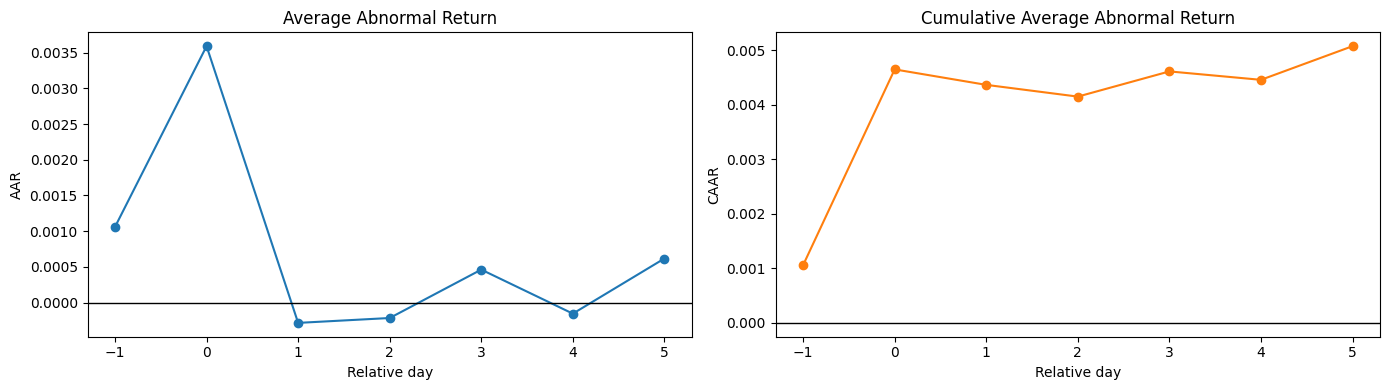

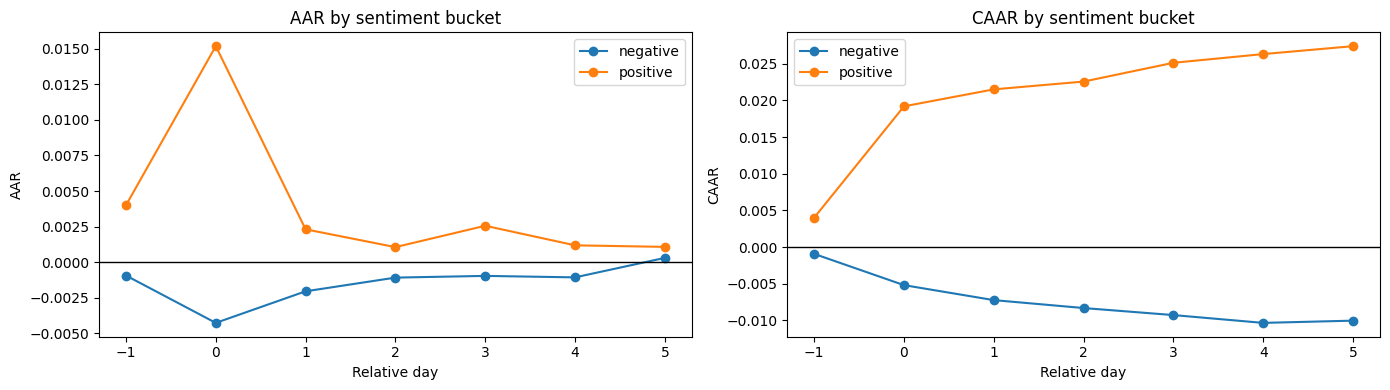

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(overall_summary.index, overall_summary['aar'], marker='o', label='AAR')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Average Abnormal Return')
axes[0].set_xlabel('Relative day')
axes[0].set_ylabel('AAR')

axes[1].plot(overall_summary.index, overall_summary['caar'], marker='o', label='CAAR', color='tab:orange')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Cumulative Average Abnormal Return')
axes[1].set_xlabel('Relative day')
axes[1].set_ylabel('CAAR')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for bucket, bucket_df in bucket_summary.groupby('sentiment_bucket'):
    axes[0].plot(bucket_df['relative_day'], bucket_df['aar'], marker='o', label=bucket)
    axes[1].plot(bucket_df['relative_day'], bucket_df['caar'], marker='o', label=bucket)

for ax, title, ylabel in [
    (axes[0], 'AAR by sentiment bucket', 'AAR'),
    (axes[1], 'CAAR by sentiment bucket', 'CAAR'),
]:
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Relative day')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()


In [8]:
toolkit_data = (
    returns.stack(dropna=True)
    .rename('ret_dlst_adj')
    .reset_index()
    .rename(columns={'level_1': 'price_ticker'})
)
toolkit_data['vwretd'] = toolkit_data['date'].map(market_ret)

toolkit_events = filtered_events[
    ['price_ticker', 'date', 'ticker', 'sentiment_bucket', 'sentiment_score_mean', 'filing_count']
].rename(columns={'date': 'EVT_DATE'})

abnormal_returns.to_parquet(OUTPUT_DIR / 'abnormal_returns.parquet', index=False)
event_level_car.to_parquet(OUTPUT_DIR / 'event_level_car.parquet', index=False)
overall_summary.reset_index().to_csv(OUTPUT_DIR / 'aar_caar_summary.csv', index=False)
bucket_summary.to_csv(OUTPUT_DIR / 'aar_caar_by_bucket.csv', index=False)
toolkit_data.to_parquet(OUTPUT_DIR / 'toolkit_data.parquet', index=False)
toolkit_events.to_parquet(OUTPUT_DIR / 'toolkit_events.parquet', index=False)

print('Saved:')
print('-', OUTPUT_DIR / 'abnormal_returns.parquet')
print('-', OUTPUT_DIR / 'event_level_car.parquet')
print('-', OUTPUT_DIR / 'aar_caar_summary.csv')
print('-', OUTPUT_DIR / 'aar_caar_by_bucket.csv')
print('-', OUTPUT_DIR / 'toolkit_data.parquet')
print('-', OUTPUT_DIR / 'toolkit_events.parquet')

display(toolkit_data.head())
display(toolkit_events.head())


C:\Users\user\AppData\Local\Temp\ipykernel_37040\1901078366.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  returns.stack(dropna=True)


Saved:
- d:\AQUMON\data\results\4\event_study_draft\abnormal_returns.parquet
- d:\AQUMON\data\results\4\event_study_draft\event_level_car.parquet
- d:\AQUMON\data\results\4\event_study_draft\aar_caar_summary.csv
- d:\AQUMON\data\results\4\event_study_draft\aar_caar_by_bucket.csv
- d:\AQUMON\data\results\4\event_study_draft\toolkit_data.parquet
- d:\AQUMON\data\results\4\event_study_draft\toolkit_events.parquet


,date,price_ticker,ret_dlst_adj,vwretd
0,2021-02-01,A.US,0.005492,0.024689
1,2021-02-01,AA.US,0.045556,0.024689
2,2021-02-01,AACG.US,0.020020,0.024689
3,2021-02-01,AAL.US,-0.019220,0.024689
4,2021-02-01,AAME.US,-0.025252,0.024689


,price_ticker,EVT_DATE,ticker,sentiment_bucket,sentiment_score_mean,filing_count
4430,A.US,2025-03-10,A,negative,-0.200000,1
6212,A.US,2025-04-03,A,negative,-0.200000,1
20127,A.US,2025-12-02,A,negative,-0.028571,7
6578,AA.US,2025-04-07,AA,positive,0.100000,1
12196,AA.US,2025-07-08,AA,positive,0.300000,1


## How To Use The Toolkit Exports

notebook ??????????????? `event-study-toolkit` ???

- `toolkit_data.parquet`
- `toolkit_events.parquet`

?????????????????

- `toolkit_events` ?? `price_ticker` ? `EVT_DATE`
- `toolkit_data` ?? `date`?`price_ticker`?`ret_dlst_adj`?`vwretd`

????????????????? `event-study-toolkit`??????????????????? toolkit ????????

## Caveats

- ?? `market_ret` ????????????????????
- ??????? `[-0.8, 0.8]` ??????????? corporate action ??? AAR ????
- ????? `sentiment_score_mean != 0` ??????????? `positive` / `negative` ???
- ??????????????????????????????? clustered inference?
